In [1]:
from sklearn.svm import SVC
import numpy as np
from tqdm import trange,tqdm
import pickle
import matplotlib.pyplot as plt
from math import ceil
import scipy
import scipy.signal
import itertools
import sys, os
import scipy.stats as sts
from scipy.stats import sem 
import numpy.random as npr
import pandas as pd
from typing import List, Tuple
from sklearn.preprocessing import StandardScaler
import ast

In [2]:
# Now try reading it
with open('C:/Users/shahe/PycharmProjects/distributed_SD/Data/filtered_mocol_categorization_bin_0.05.pkl', 'rb') as f:
    data = pickle.load(f)

# Now, you can work with loaded_data
print(data.keys())

dict_keys(['trial', 'unit', 'session', 'spikecounts', 'trialsNeuron'])


In [3]:
for i, df in enumerate(data['trial']):
    if 'chosenResponse' in df.columns and 'expectedResponse' in df.columns:
        def clean(val):
            if isinstance(val, np.ndarray):
                return str(val[0]) if len(val) > 0 else None
            return str(val) if val is not None else None

        df['chosenResponse'] = df['chosenResponse'].apply(clean)
        df['expectedResponse'] = df['expectedResponse'].apply(clean)
        df['color'] = df['color']/90
        df['direction'] = df['direction']/90
        data['trial'][i] = df  # Save cleaned DataFrame back
    else:
        print(f"Session {i}: Missing required columns.")


for i, df in enumerate(data['trial']):
    if 'chosenResponse' in df.columns and 'expectedResponse' in df.columns:
        # Map values
        df['chosenResponse'] = df['chosenResponse'].map({'L': 1, 'R': 0})
        df['expectedResponse'] = df['expectedResponse'].map({'L': 1, 'R': 0})
        data['trial'][i] = df  # Save updated DataFrame back
    else:
        print(f"Session {i}: Missing required columns.")

for i, df in enumerate(data['trial']):
    if 'rule' in df.columns:
        # Extract the string from the array and map it to numeric
        df['rule'] = df['rule'].apply(
            lambda x: 1 if isinstance(x, (list, np.ndarray)) and 'color' in x else
                      -1 if isinstance(x, (list, np.ndarray)) and 'motion' in x else
                      np.nan  # fallback for unexpected format
        )
        data['trial'][i] = df  # Update cleaned DataFrame

In [4]:
data = data['trial']

In [ ]:
def process_session_data(df):
    """
    Process a single session DataFrame.
    Cleans and adds derived variables for analysis.
    """
    df = df.copy()
    scaler = StandardScaler()

    # Basic columns
    df['intercept'] = 1

    # Standardize variables

    df['color_z'] = df['color']
    df['direction_z'] = df['direction']
    # z score
    #df['color_z'] = scaler.fit_transform(df[['color_z']])
    #df['direction_z'] = scaler.fit_transform(df[['direction_z']])


    # Previous trial variables
    df['p_color_z'] = df['color_z'].shift(1)
    df['p_direction_z'] = df['direction_z'].shift(1)

    # Map 'L' and 'R' to 1 and 0
    df['chosenResponse'] = df['chosenResponse']

    # relevant stimulus when rule is 1 --> color and when rule is -1 --> motion
    df['relevant_stim'] = df.apply(
        lambda row: row['color_z'] if row['rule'] == 1 else row['direction_z'], axis=1
    )
    df['irrelevant_stim'] = df.apply(
        lambda row: row['direction_z'] if row['rule'] == 1 else row['color_z'], axis=1
    )

    df['prev_relevant_stim'] = df['relevant_stim'].shift(1)
    df['prev_irrelevant_stim'] = df['irrelevant_stim'].shift(1)




    df['prev_response'] = df['chosenResponse'].shift(1)

    # Map and encode rule
    df['context']  = df['rule']
    df['prob_color'] = np.where(df['context'] == 1, 1, 0)
    df['prob_motion'] = np.where(df['context'] == 0, 1, 0)

    df['prev_context'] = df['context'].shift(1)

    df['context_color'] = df['color_z'] * df['context']
    df['context_motion'] = df['direction_z'] * df['context']
    df['prev_context_color'] = df['prev_context'] * df['p_color_z']
    df['prev_context_motion'] = df['prev_context'] * df['p_direction_z']


    # zcroe
    #df['context_color'] = scaler.fit_transform(df[['context_color']])
    #df['context_motion'] = scaler.fit_transform(df[['context_motion']])


    df['dist_prev_current_color'] = abs(df['color_z'] - df['p_color_z'])
    df['dist_prev_current_motion'] = abs(df['direction_z'] - df['p_direction_z'])

    
    # ---------------- Add correctness stimulus classification ----------------
    # ---------------- Correctness stimulus classification ----------------
    # We create: correctness_stim_type in {'LL','RR','LR','RL','neutral'}
    # and a flag irr_neutral (True if irrelevant stimulus == 0)
    # ------------------------------------
    # BEFORE any assignment, create as object dtype
    # ------------------------------------
    # ---------------- Correctness stimulus classification ----------------
    # ---------------- Correctness stimulus classification (per your spec) ----------------
    # 0) Prep: ensure the label column can hold strings
    df['correctness_stim_type'] = pd.Series(pd.NA, index=df.index, dtype='object')
    df['irr_neutral'] = False  # flag only
    
    # 1) Relevant context column (and a convenience 'relevant_stim')
    #    context: 1 -> color relevant, -1 -> motion relevant
    df['relevant_context'] = np.where(df['context'] == 1, 'color', 'motion')
    df['relevant_stim']    = np.where(df['context'] == 1, df['color_z'], df['direction_z'])
    df['irrelevant_stim']  = np.where(df['context'] == 1, df['direction_z'], df['color_z'])
    
    # 2) Identify neutral trials: relevant stimulus == 0
    neutral_mask = (df['relevant_stim'] == 0)
    df.loc[neutral_mask, 'correctness_stim_type'] = 'neutral'
    
    # 3) Excluding the neutral trials, classify LL/RR/LR/RL on the rest
    #    Use L := (stim >= 0), R := (stim < 0)
    classify_mask = ~neutral_mask & df['color_z'].notna() & df['direction_z'].notna() & df['context'].isin([1, -1])
    
    side_color = np.where(df['color_z'] >= 0, 'L', 'R')
    side_dir   = np.where(df['direction_z'] >= 0, 'L', 'R')
    labels = pd.Series(side_color + side_dir, index=df.index, dtype='object')
    
    df.loc[classify_mask, 'correctness_stim_type'] = labels.loc[classify_mask]
    
    # 4) Flag when the IRRELEVANT stimulus is zero (not a separate group)
    irr_neutral_mask = (df['irrelevant_stim'] == 0)
    df.loc[irr_neutral_mask, 'irr_neutral'] = True


    # conver correctness to numbers
    #df['correctness_stim_type'] = df['correctness_stim_type'].map({'LL': 0, 'RR': 1, 'LR': 2, 'RL': 3, 'NaN': np.nan})


    cue_dummies = pd.get_dummies(df['cue'], prefix='cue', drop_first=False)
    df = pd.concat([df, cue_dummies], axis=1)  # <- add this line

    # ---------------- Add is_correct ----------------
    # 1 if chosenResponse == expectedResponse
    # 0 if not equal
    # 2 if expectedResponse is NaN
    is_nan_exp = df['expectedResponse'].isna()
    matches = df['chosenResponse'] == df['expectedResponse']
    df['is_correct'] = np.select([is_nan_exp, matches], [2, 1], default=0).astype(int)

    # probability correct and incorect
    df['prob_correct'] = np.where(df['is_correct'] == 1, 1, 0)
    df['prob_incorrect'] = np.where(df['is_correct'] == 0, 1, 0)
    df['prob_neurtral'] = np.where(df['is_correct'] == 2, 1, 0)


    # let's create a column called congruency where is a trial is different context/rule from the previous than  it is incongruent (0) otherwise 1
    df['congruency'] = np.where(
        df['context'] != df['prev_context'], 0, 1
    ).astype(int)
    
    df['reward'] = np.where(df['numRewards'] > 0, 1, 0)

    # sign-based stimulus congruency
    df['stim_congruency'] = np.where(
        np.sign(df['color_z']) == np.sign(df['direction_z']),
        1,  # congruent
        0   # incongruent
    ).astype(int)
    



    
    # Keep only trials that are correct AND not bad timing
    # Keep only correct trials and those with a defined expected response
    #good_mask = (df['correct'] == 1) & (df['expectedResponse'].notna())
    
    
    # Apply filter
    #df_filtered = df[good_mask].reset_index(drop=True)
    #df_hmm_glm = df['badTimingTrials'] == 0 #&(~df['expectedResponse'].isna())]
    good_mask = df['badTimingTrials'] == 0
    #good_mask = df['expectedResponse'].notna() # df['correct'] == 1 #) & 
    
    # Apply filter
    df_filtered = df[good_mask].reset_index(drop=True)
        # Scale reactionTime
    df_filtered['reactionTime_z'] = scaler.fit_transform(df_filtered[['reactionTime']])
    
    df_filtered['RTxprev_Response'] = df_filtered['reactionTime_z'] * df_filtered['prev_response']
    df_filtered['RTxprev_Response'] =  scaler.fit_transform(df_filtered[['RTxprev_Response']])
    
    
    
    # Return the filtered DataFrame
    return df_filtered

def prepare_data_for_glmhmm_sessionwise(data):
    """
    Prepares input features and responses for HMM-GLM model fitting.
    Returns separate input arrays per session (no concatenation).
    """
    inpts = []
    true_choices = []
    session_lengths = []

    for df in data:
        # Extract features
        color         = -df[['color_z']].fillna(0).to_numpy()
        motion        = -df[['direction_z']].fillna(0).to_numpy()
        p_color       = -df[['p_color_z']].fillna(0).to_numpy()
        dist_prev_c   = -df[['dist_prev_current_color']].fillna(0).to_numpy()
        p_motion      = -df[['p_direction_z']].fillna(0).to_numpy()
        dist_prev_m   = -df[['dist_prev_current_motion']].fillna(0).to_numpy()
        prev_response = -df[['prev_response']].fillna(0).to_numpy()
        RT            = -df[['reactionTime_z']].fillna(0).to_numpy()
        context      = -df[['context']].fillna(0).to_numpy()
        context_color = -df[['context_color']].fillna(0).to_numpy()
        context_motion = -df[['context_motion']].fillna(0).to_numpy()

        RTxprev_response = -df[['RTxprev_Response']].fillna(0).to_numpy()
        bias          = -df[['intercept']].fillna(0).to_numpy()

        relevant_stim = -df[['relevant_stim']].fillna(0).to_numpy()
        irrelevant_stim = -df[['irrelevant_stim']].fillna(0).to_numpy()

        prev_relevant_stim = -df[['prev_relevant_stim']].fillna(0).to_numpy()
        prev_irrelevant_stim = -df[['prev_irrelevant_stim']].fillna(0).to_numpy()
        prev_context_color = -df[['prev_context_color']].fillna(0).to_numpy()
        prev_context_motion = -df[['prev_context_motion']].fillna(0).to_numpy()
        congruency          = -df[['congruency']].fillna(0).to_numpy()
        #correctness_stim_type = -df[['correctness_stim_type']].fillna(0).to_numpy()
        reward             = -df[['reward']].fillna(0).to_numpy()



        cue_cols = [col for col in df.columns if col.startswith('cue_')]
        cue_dummies = -df[cue_cols].astype(int).to_numpy()

        # Combine features into design matrix
        X = np.hstack([
            #color,
            #motion,
            #p_color,
            #dist_prev_c,
            #p_motion,
            #dist_prev_m,
            relevant_stim,
            irrelevant_stim,
            prev_relevant_stim,
            prev_irrelevant_stim,
            prev_response,
            #congruency,
            #correctness_stim_type,
            #cue_dummies,
            #context,
            #RTxprev_response,
            bias
        ])

        # Response
        y = df['chosenResponse'].fillna(0).astype(int).to_numpy().reshape(-1, 1)

        # Append per-session arrays
        inpts.append(X)
        true_choices.append(y)
        session_lengths.append(len(df))

    return inpts, true_choices, session_lengths
# Process each session individually
processed_data = [process_session_data(df) for df in data]

# Prepare data for fitting
inpts, true_choices, session_lengths = prepare_data_for_glmhmm_sessionwise(processed_data)

# Check
print("Number of sessions:", len(inpts))             # ✅ should equal number of sessions
print("Trials per session:", session_lengths)
num_states = 2
obs_dim = 1
input_dim = inpts[0].shape[1]  # Number of features in the input



C:\Users\shahe\AppData\Local\Temp\ipykernel_24540\2779070064.py:25: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(arr, axis=0)


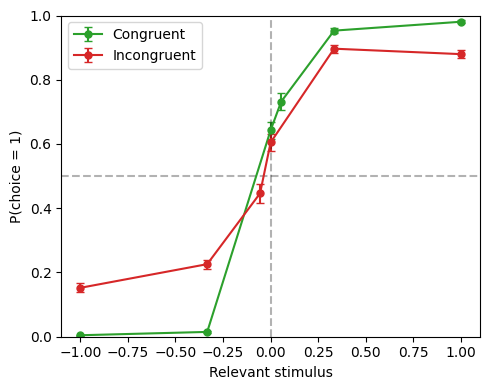

In [16]:
def signed_pos(x):
    return np.where(x >= 0, 1, -1)

# define stim grid (across sessions)
stim_vals = np.sort(
    np.unique(
        np.concatenate([d['relevant_stim'].dropna().to_numpy() for d in processed_data])
    )
)

def session_psychometric(df, stim_vals):
    probs = np.full(len(stim_vals), np.nan)
    for i, stim in enumerate(stim_vals):
        m = df['relevant_stim'] == stim
        if m.any():
            probs[i] = df.loc[m, 'chosenResponse'].mean()
    return probs

def mean_sem(curve_list):
    arr = np.vstack(curve_list)  # n_sessions x n_stim
    mean = np.nanmean(arr, axis=0)
    n = np.sum(~np.isnan(arr), axis=0)
    sem = np.nanstd(arr, axis=0, ddof=1) / np.sqrt(n)
    return mean, sem

curves = defaultdict(list)

for sess_df in processed_data:
    sess_df = sess_df.copy()

    # ADD congruency here (0 treated as positive)
    sess_df['stim_congruency'] = (
        signed_pos(sess_df['color_z'].to_numpy()) == signed_pos(sess_df['direction_z'].to_numpy())
    ).astype(int)

    for cong in [1, 0]:
        df_sub = sess_df[sess_df['stim_congruency'] == cong]
        if len(df_sub) < 5:
            continue
        curves[cong].append(session_psychometric(df_sub, stim_vals))

plt.figure(figsize=(5, 4))

for cong, color, label in zip(
    [1, 0],
    ['tab:green', 'tab:red'],
    ['Congruent', 'Incongruent']
):
    if cong not in curves or len(curves[cong]) < 2:
        continue

    mean, sem = mean_sem(curves[cong])

    # mask valid points
    valid = ~np.isnan(mean)

    plt.errorbar(
        stim_vals[valid],
        mean[valid],
        yerr=sem[valid],
        fmt='o-',              # dots + CONNECTED line
        color=color,
        capsize=3,
        linewidth=1.5,
        markersize=5,
        label=label
    )

plt.axhline(0.5, color='k', linestyle='--', alpha=0.3)
plt.axvline(0, color='k', linestyle='--', alpha=0.3)
plt.ylim(0, 1)

plt.xlabel('Relevant stimulus')
plt.ylabel('P(choice = 1)')
plt.legend()
plt.tight_layout()
plt.show()


C:\Users\shahe\AppData\Local\Temp\ipykernel_24540\2369591351.py:25: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(arr, axis=0)
C:\Users\shahe\miniconda3\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2053: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


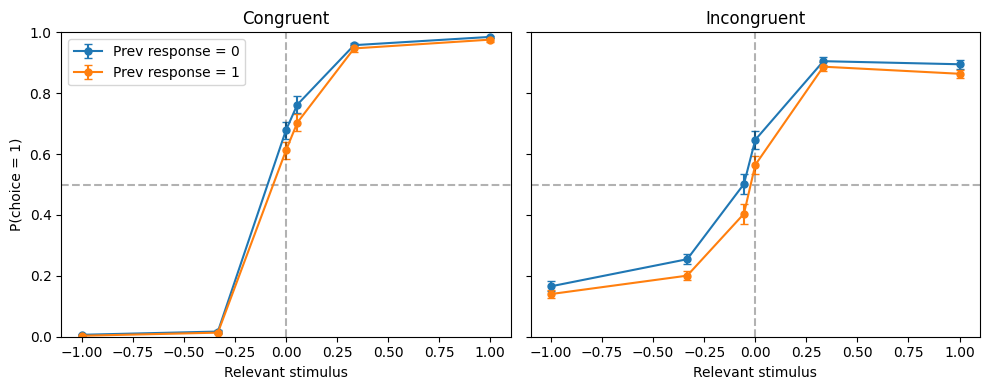

In [17]:
def signed_pos(x):
    return np.where(x >= 0, 1, -1)

# define stim grid (across sessions)
stim_vals = np.sort(
    np.unique(
        np.concatenate([d['relevant_stim'].dropna().to_numpy() for d in processed_data])
    )
)

def session_psychometric(df, stim_vals):
    probs = np.full(len(stim_vals), np.nan)
    for i, stim in enumerate(stim_vals):
        m = df['relevant_stim'] == stim
        if m.any():
            probs[i] = df.loc[m, 'chosenResponse'].mean()
    return probs

def mean_sem(curve_list):
    arr = np.vstack(curve_list)  # n_sessions x n_stim
    mean = np.nanmean(arr, axis=0)
    n = np.sum(~np.isnan(arr), axis=0)
    sem = np.nanstd(arr, axis=0, ddof=1) / np.sqrt(n)
    return mean, sem

# curves[(cong, prev_resp)] = list of session curves
curves = defaultdict(list)

for sess_df in processed_data:
    sess_df = sess_df.copy()

    # stimulus congruency (0 treated as positive)
    sess_df['stim_congruency'] = (
        signed_pos(sess_df['color_z'].to_numpy()) == signed_pos(sess_df['direction_z'].to_numpy())
    ).astype(int)

    # drop trials without prev_response (first trial)
    sess_df = sess_df.dropna(subset=['prev_response'])

    for cong in [1, 0]:
        for prev_resp in [0, 1]:
            df_sub = sess_df[
                (sess_df['stim_congruency'] == cong) &
                (sess_df['prev_response'] == prev_resp)
            ]

            if len(df_sub) < 5:
                continue

            curves[(cong, prev_resp)].append(session_psychometric(df_sub, stim_vals))

# ---- Plot: 2 panels (congruent/incongruent), 2 curves each (prev_resp 0/1) ----
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, cong, title in zip(axes, [1, 0], ['Congruent', 'Incongruent']):
    for prev_resp, color, label in zip(
        [0, 1],
        ['tab:blue', 'tab:orange'],
        ['Prev response = 0', 'Prev response = 1']
    ):
        key = (cong, prev_resp)
        if key not in curves or len(curves[key]) < 2:
            continue

        mean, sem = mean_sem(curves[key])
        valid = ~np.isnan(mean)

        ax.errorbar(
            stim_vals[valid],
            mean[valid],
            yerr=sem[valid],
            fmt='o-',
            color=color,
            capsize=3,
            linewidth=1.5,
            markersize=5,
            label=label
        )

    ax.axhline(0.5, color='k', linestyle='--', alpha=0.3)
    ax.axvline(0, color='k', linestyle='--', alpha=0.3)
    ax.set_title(title)
    ax.set_xlabel('Relevant stimulus')
    ax.set_ylim(0, 1)

axes[0].set_ylabel('P(choice = 1)')
axes[0].legend()
plt.tight_layout()
plt.show()


In [22]:
def predict_logistic_with_lapses(X, params):
    beta = params[:-2]
    gamma_r = params[-2]
    gamma_l = params[-1]
    logits = X @ beta
    p = 1 / (1 + np.exp(-logits))
    return gamma_l + (1 - gamma_l - gamma_r) * p

def neg_log_likelihood(params, X, y):
    p = predict_logistic_with_lapses(X, params)
    eps = 1e-9
    return -np.sum(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

def fit_with_mle(X, y):
    n_features = X.shape[1]
    p0 = [0.1] * n_features + [0.05, 0.05]  # init weights + lapse params
    bounds = [(-10, 10)] * n_features + [(0, 0.49), (0, 0.49)]
    result = minimize(neg_log_likelihood, p0, args=(X, y), method='L-BFGS-B', bounds=bounds)
    if result.success:
        return result.x
    else:
        raise RuntimeError("Fitting failed")

In [ ]:
regressor_labels = [
    "color", "motion", "prev_color",  "prev_motion",  #"dist_prev_col", "dist_prev_mot","prev_rewarded_loc",
    "prev_response",  "bias",    # "color_ctx","direction_ctx", "bias", "context_prev_resp", "color_ctx", "direction_ctx", "prev_reward", "is_switch",
    "gamma_r", "gamma_l"
]
all_params = []
for X, y in zip(inpts, true_choices):
    y = y.flatten()
    try:
        fitted_params = fit_with_mle(X, y)
        all_params.append(fitted_params)
    except RuntimeError:
        print("MLE failed.")
        all_params.append(np.full(X.shape[1] + 2, np.nan))

# Step 4: Store as DataFrame for easy access
betas_df = pd.DataFrame(all_params, columns=regressor_labels)

# Step 5: Compute group-level stats
mean_params = betas_df.mean(skipna=True)
std_params = betas_df.std(skipna=True)
ci95_params = 1.96 * std_params / np.sqrt(betas_df.notna().sum())

# -------------------------------
# --- Plot: Weights + Lapses ---
# -------------------------------
plt.figure(figsize=(12, 5))
plt.errorbar(
    range(len(mean_params)), mean_params, yerr=ci95_params, fmt='o',
    capsize=5, color='black', ecolor='gray'
)
plt.axhline(0, linestyle='--', color='gray')
plt.xticks(range(len(mean_params)), regressor_labels, rotation=45)
plt.ylabel('Parameter Estimate')
plt.title('GLM Regressor Weights and Lapse Rates with 95% CI')
plt.tight_layout()
plt.show()

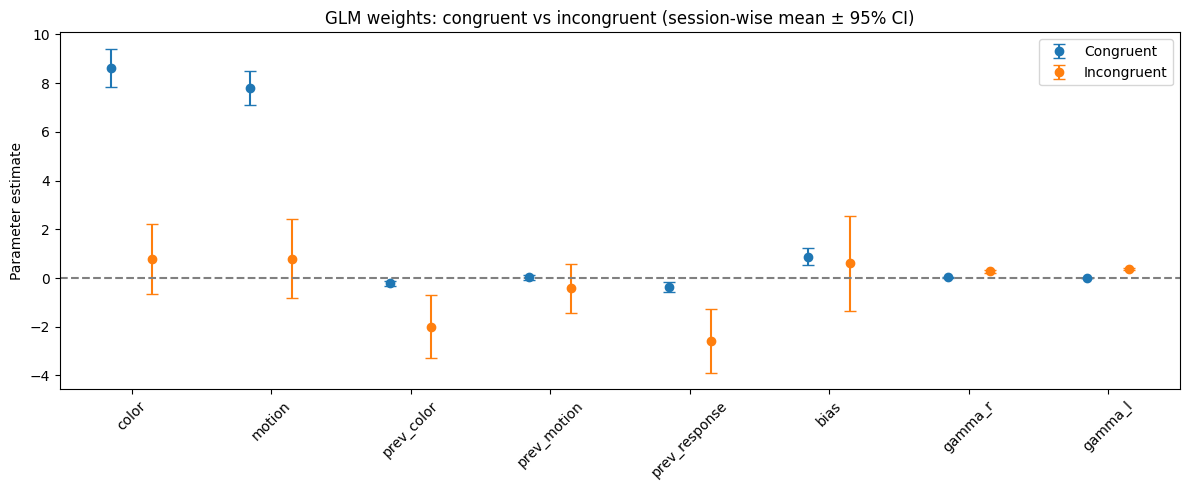

In [24]:
def signed_pos(x):
    return np.where(x >= 0, 1, -1)

# Choose which columns to use (robust fallback)
def get_col(df, preferred, fallback):
    if preferred in df.columns:
        return preferred
    if fallback in df.columns:
        return fallback
    raise KeyError(f"Neither {preferred} nor {fallback} found in columns: {list(df.columns)}")

def build_Xy_from_df(df):
    # use z columns if they exist, otherwise raw
    ccol = get_col(df, "color_z", "color")
    dcol = get_col(df, "direction_z", "direction")
    pccol = get_col(df, "p_color_z", None) if "p_color_z" in df.columns else None
    pdcol = get_col(df, "p_direction_z", None) if "p_direction_z" in df.columns else None

    # if p_* not present, create them on the fly
    if pccol is None:
        df = df.copy()
        df["p_color_z"] = df[ccol].shift(1)
        pccol = "p_color_z"
    if pdcol is None:
        df = df.copy()
        df["p_direction_z"] = df[dcol].shift(1)
        pdcol = "p_direction_z"

    # prev_response + intercept must exist; if not, create them
    if "prev_response" not in df.columns:
        df = df.copy()
        df["prev_response"] = df["chosenResponse"].shift(1)
    if "intercept" not in df.columns:
        df = df.copy()
        df["intercept"] = 1

    X = np.hstack([
        df[[ccol]].fillna(0).to_numpy(),
        df[[dcol]].fillna(0).to_numpy(),
        df[[pccol]].fillna(0).to_numpy(),
        df[[pdcol]].fillna(0).to_numpy(),
        df[['prev_response']].fillna(0).to_numpy(),
        df[['intercept']].fillna(0).to_numpy(),
    ])

    y = df['chosenResponse'].astype(int).to_numpy()
    return X, y, df  # return df in case we created columns

# Your labels MUST match what build_Xy_from_df returns (+2 lapse params)
regressor_labels = ["color", "motion", "prev_color", "prev_motion", "prev_response", "bias", "gamma_r", "gamma_l"]

params_cong = []
params_incong = []

for sess_df in processed_data:
    sess_df = sess_df.copy()

    ccol = get_col(sess_df, "color_z", "color")
    dcol = get_col(sess_df, "direction_z", "direction")

    # define stim congruency with 0 as positive
    sess_df["stim_congruency"] = (
        signed_pos(sess_df[ccol].to_numpy()) == signed_pos(sess_df[dcol].to_numpy())
    ).astype(int)

    # drop first trial (prev vars undefined)
    # NOTE: prev_response might already exist; if not, build_Xy will create it,
    # but for filtering we can do it here safely:
    if "prev_response" in sess_df.columns:
        sess_df = sess_df.dropna(subset=["prev_response"])
    else:
        sess_df["prev_response"] = sess_df["chosenResponse"].shift(1)
        sess_df = sess_df.dropna(subset=["prev_response"])

    # --- Congruent ---
    df_c = sess_df[sess_df["stim_congruency"] == 1]
    if len(df_c) >= 10:
        Xc, yc, _ = build_Xy_from_df(df_c)
        try:
            params_cong.append(fit_with_mle(Xc, yc))  # should return (n_features + 2,) vector
        except RuntimeError:
            params_cong.append(np.full(Xc.shape[1] + 2, np.nan))
    else:
        params_cong.append(np.full(6 + 2, np.nan))  # 6 regressors + 2 lapse

    # --- Incongruent ---
    df_i = sess_df[sess_df["stim_congruency"] == 0]
    if len(df_i) >= 10:
        Xi, yi, _ = build_Xy_from_df(df_i)
        try:
            params_incong.append(fit_with_mle(Xi, yi))
        except RuntimeError:
            params_incong.append(np.full(Xi.shape[1] + 2, np.nan))
    else:
        params_incong.append(np.full(6 + 2, np.nan))

betas_cong = pd.DataFrame(params_cong, columns=regressor_labels)
betas_incong = pd.DataFrame(params_incong, columns=regressor_labels)

def mean_ci(df):
    mean = df.mean(skipna=True)
    n = df.notna().sum()
    sem = df.std(skipna=True, ddof=1) / np.sqrt(n)
    ci95 = 1.96 * sem
    return mean, ci95

mean_c, ci_c = mean_ci(betas_cong)
mean_i, ci_i = mean_ci(betas_incong)

x = np.arange(len(regressor_labels))
dx = 0.15

plt.figure(figsize=(12, 5))
plt.errorbar(x - dx, mean_c, yerr=ci_c, fmt='o', capsize=4, label='Congruent')
plt.errorbar(x + dx, mean_i, yerr=ci_i, fmt='o', capsize=4, label='Incongruent')
plt.axhline(0, linestyle='--', color='gray')
plt.xticks(x, regressor_labels, rotation=45)
plt.ylabel("Parameter estimate")
plt.title("GLM weights: congruent vs incongruent (session-wise mean ± 95% CI)")
plt.legend()
plt.tight_layout()
plt.show()


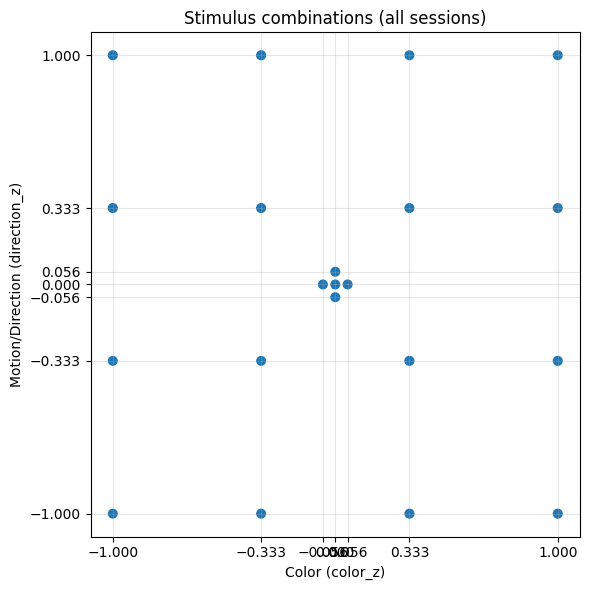

In [10]:
def plot_stimulus_grid(processed_data, session_idx=None, size_by_count=True, ax=None):
    # Pick one session or concatenate all
    if session_idx is None:
        df = pd.concat(processed_data, ignore_index=True)
        title = "Stimulus combinations (all sessions)"
    else:
        df = processed_data[session_idx].copy()
        title = f"Stimulus combinations (session {session_idx})"

    # Keep only valid rows
    df = df[['color_z', 'direction_z']].dropna()

    # Count occurrences per combination
    counts = (
        df.groupby(['color_z', 'direction_z'])
          .size()
          .reset_index(name='count')
    )

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    if size_by_count:
        # Scale sizes a bit for visibility
        s = 30 + 10 * (counts['count'] / counts['count'].max())
    else:
        s = 60

    ax.scatter(counts['color_z'], counts['direction_z'], s=s)

    ax.set_xlabel("Color (color_z)")
    ax.set_ylabel("Motion/Direction (direction_z)")
    ax.set_title(title)

    # Put ticks exactly at the unique values used
    ax.set_xticks(np.sort(df['color_z'].unique()))
    ax.set_yticks(np.sort(df['direction_z'].unique()))

    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return ax

# Example usage:
plot_stimulus_grid(processed_data)          # all sessions
# plot_stimulus_grid(processed_data, 0)     # session 0
plt.show()


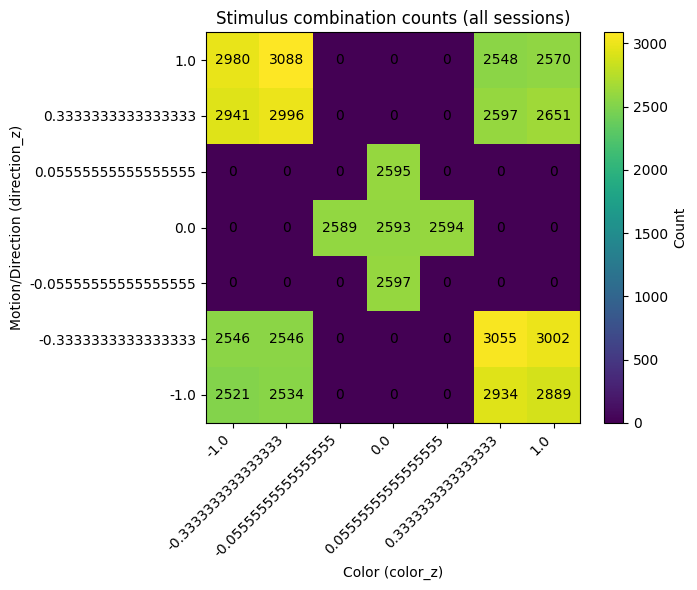

In [11]:
def plot_stimulus_heatmap(processed_data, session_idx=None, ax=None):
    if session_idx is None:
        df = pd.concat(processed_data, ignore_index=True)
        title = "Stimulus combination counts (all sessions)"
    else:
        df = processed_data[session_idx].copy()
        title = f"Stimulus combination counts (session {session_idx})"

    df = df[['color_z', 'direction_z']].dropna()

    # pivot table: rows=direction, cols=color
    pivot = pd.pivot_table(
        df,
        index='direction_z',
        columns='color_z',
        values='color_z',
        aggfunc='size',
        fill_value=0
    ).sort_index(axis=0).sort_index(axis=1)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))

    im = ax.imshow(pivot.to_numpy(), aspect='auto', origin='lower')

    ax.set_title(title)
    ax.set_xlabel("Color (color_z)")
    ax.set_ylabel("Motion/Direction (direction_z)")

    ax.set_xticks(np.arange(pivot.shape[1]))
    ax.set_xticklabels(pivot.columns.to_list(), rotation=45, ha='right')
    ax.set_yticks(np.arange(pivot.shape[0]))
    ax.set_yticklabels(pivot.index.to_list())

    # annotate counts
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, int(pivot.iat[i, j]), ha='center', va='center')

    plt.colorbar(im, ax=ax, label="Count")
    plt.tight_layout()
    return pivot, ax

# Example usage:
pivot, ax = plot_stimulus_heatmap(processed_data)
plt.show()


In [12]:

def stimulus_combo_report(processed_data, session_idx=None):
    if session_idx is None:
        df = pd.concat(processed_data, ignore_index=True)
    else:
        df = processed_data[session_idx].copy()

    df = df[['color_z', 'direction_z']].dropna()

    unique_colors = np.sort(df['color_z'].unique())
    unique_dirs   = np.sort(df['direction_z'].unique())

    all_possible = pd.MultiIndex.from_product(
        [unique_colors, unique_dirs],
        names=['color_z', 'direction_z']
    ).to_frame(index=False)

    used = df.drop_duplicates(['color_z', 'direction_z'])[['color_z', 'direction_z']]

    merged = all_possible.merge(used.assign(used=1), on=['color_z','direction_z'], how='left')
    merged['used'] = merged['used'].fillna(0).astype(int)

    n_all = len(all_possible)
    n_used = merged['used'].sum()
    n_missing = n_all - n_used

    return merged, unique_colors, unique_dirs, (n_all, n_used, n_missing)

report, colors, dirs, summary = stimulus_combo_report(processed_data)
print("Total possible combos (unique color x unique motion):", summary[0])
print("Used combos:", summary[1])
print("Missing combos:", summary[2])

# missing combos list:
missing = report[report['used'] == 0]
missing.head()


Total possible combos (unique color x unique motion): 49
Used combos: 21
Missing combos: 28


,color_z,direction_z,used
2,-1.000000,-0.055556,0
3,-1.000000,0.000000,0
4,-1.000000,0.055556,0
9,-0.333333,-0.055556,0
10,-0.333333,0.000000,0


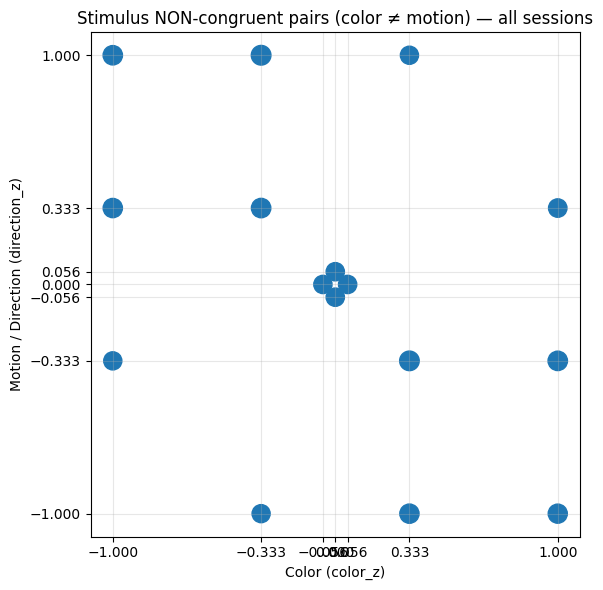

Number of unique NON-congruent pairs (color ≠ motion): 16
  color_z  direction_z  count
-1.000000    -0.333333   2546
-1.000000     0.333333   2941
-1.000000     1.000000   2980
-0.333333    -1.000000   2534
-0.333333     0.333333   2996
-0.333333     1.000000   3088
-0.055556     0.000000   2589
 0.000000    -0.055556   2597
 0.000000     0.055556   2595
 0.055556     0.000000   2594
 0.333333    -1.000000   2934
 0.333333    -0.333333   3055
 0.333333     1.000000   2548
 1.000000    -1.000000   2889
 1.000000    -0.333333   3002
 1.000000     0.333333   2651


In [16]:
def plot_and_print_noncongruent_pairs_eq(processed_data, session_idx=None, size_by_count=True):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    # Select data
    if session_idx is None:
        df = pd.concat(processed_data, ignore_index=True)
        title = "Stimulus NON-congruent pairs (color ≠ motion) — all sessions"
    else:
        df = processed_data[session_idx].copy()
        title = f"Stimulus NON-congruent pairs (color ≠ motion) — session {session_idx}"

    # Keep valid stimulus rows
    df = df[['color_z', 'direction_z']].dropna()

    # Non-congruent = not equal
    df_nc = df[df['color_z'] != df['direction_z']]

    if df_nc.empty:
        print("No non-congruent stimulus pairs found (color_z != direction_z).")
        return None

    # Count unique pairs
    pairs = (
        df_nc.groupby(['color_z', 'direction_z'])
             .size()
             .reset_index(name='count')
             .sort_values(['color_z', 'direction_z'])
             .reset_index(drop=True)
    )

    # Plot
    fig, ax = plt.subplots(figsize=(6, 6))
    if size_by_count:
        s = 30 + 170 * (pairs['count'] / pairs['count'].max())
    else:
        s = 80

    ax.scatter(pairs['color_z'], pairs['direction_z'], s=s)

    ax.set_xlabel("Color (color_z)")
    ax.set_ylabel("Motion / Direction (direction_z)")
    ax.set_title(title)

    ax.set_xticks(np.sort(df_nc['color_z'].unique()))
    ax.set_yticks(np.sort(df_nc['direction_z'].unique()))
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Print results
    print(f"Number of unique NON-congruent pairs (color ≠ motion): {len(pairs)}")
    print(pairs.to_string(index=False))

    return pairs
# All sessions pooled
nc_pairs_all = plot_and_print_noncongruent_pairs_eq(processed_data)

# Single session
# nc_pairs_s0 = plot_and_print_noncongruent_pairs_eq(processed_data, session_idx=0)


C:\Users\shahe\AppData\Local\Temp\ipykernel_9488\886932402.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_counts.index, y=group_counts.values, palette="muted")


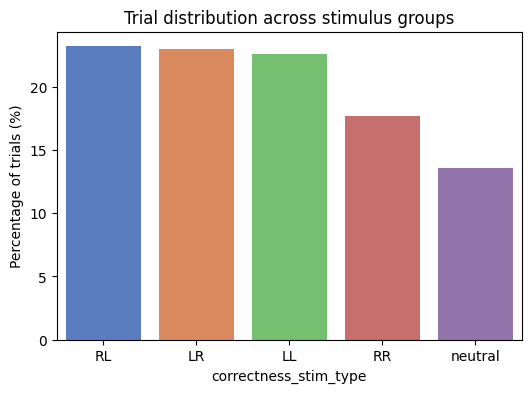

C:\Users\shahe\AppData\Local\Temp\ipykernel_9488\886932402.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pair_counts.index, y=pair_counts.values, palette="Set2")


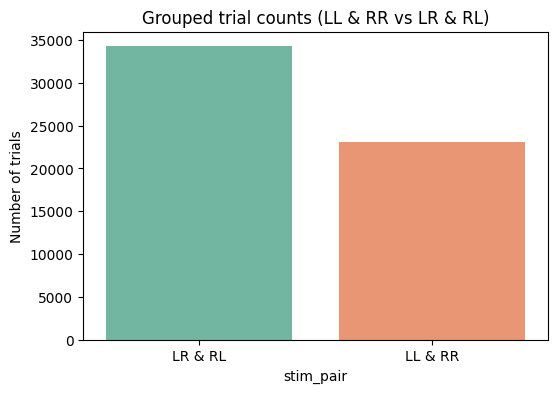

C:\Users\shahe\AppData\Local\Temp\ipykernel_9488\886932402.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Perceptual' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_valid.loc[(df_valid['is_correct'] == 0) & (df_valid['stim_pair'] == 'LL & RR'), 'error_type'] = 'Perceptual'
C:\Users\shahe\AppData\Local\Temp\ipykernel_9488\886932402.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=error_counts.index, y=error_counts.values, palette="pastel")


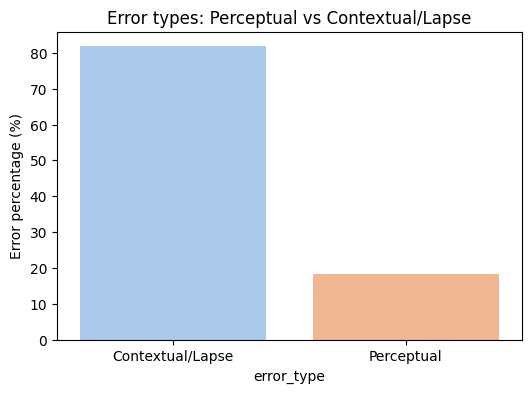

C:\Users\shahe\AppData\Local\Temp\ipykernel_9488\886932402.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=error_rates.index, y=error_rates.values, palette="coolwarm")


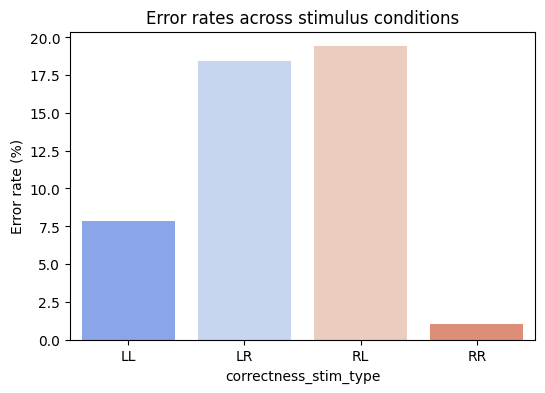

In [38]:
# Concatenate all sessions into one dataframe
all_df = pd.concat(data, ignore_index=True)

# ---------------------------
# 1. Percentage of trials in each group (LL, RR, LR, RL)
# ---------------------------
group_counts = all_df['correctness_stim_type'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=group_counts.index, y=group_counts.values, palette="muted")
plt.ylabel("Percentage of trials (%)")
plt.title("Trial distribution across stimulus groups")
plt.show()

# ---------------------------
# 2. Compare (LL & RR) vs (LR & RL)
# ---------------------------
all_df['stim_pair'] = np.where(all_df['correctness_stim_type'].isin(['LL', 'RR']), 'LL & RR', 'LR & RL')
pair_counts = all_df['stim_pair'].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=pair_counts.index, y=pair_counts.values, palette="Set2")
plt.ylabel("Number of trials")
plt.title("Grouped trial counts (LL & RR vs LR & RL)")
plt.show()

# ---------------------------
# 3. Perceptual vs Contextual/Lapse errors
# ---------------------------
# Exclude neutral trials (is_correct == 2)
df_valid = all_df[all_df['is_correct'] != 2].copy()

df_valid['error_type'] = np.nan
df_valid.loc[(df_valid['is_correct'] == 0) & (df_valid['stim_pair'] == 'LL & RR'), 'error_type'] = 'Perceptual'
df_valid.loc[(df_valid['is_correct'] == 0) & (df_valid['stim_pair'] == 'LR & RL'), 'error_type'] = 'Contextual/Lapse'

error_counts = df_valid['error_type'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
sns.barplot(x=error_counts.index, y=error_counts.values, palette="pastel")
plt.ylabel("Error percentage (%)")
plt.title("Error types: Perceptual vs Contextual/Lapse")
plt.show()

# ---------------------------
# 4. Error rates in each condition (LL, RR, RL, LR)
# ---------------------------
error_rates = (
    df_valid.groupby('correctness_stim_type')['is_correct']
    .apply(lambda x: (x == 0).mean() * 100)  # % errors
)

plt.figure(figsize=(6, 4))
sns.barplot(x=error_rates.index, y=error_rates.values, palette="coolwarm")
plt.ylabel("Error rate (%)")
plt.title("Error rates across stimulus conditions")
plt.show()


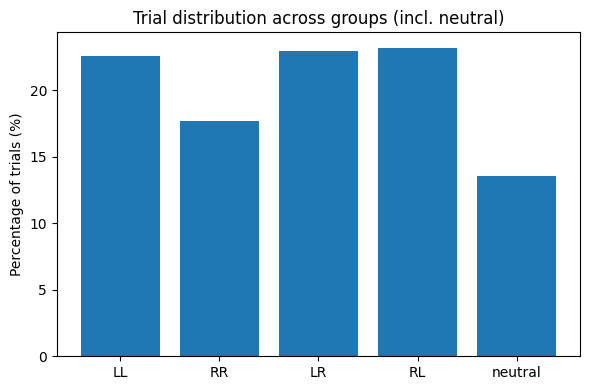

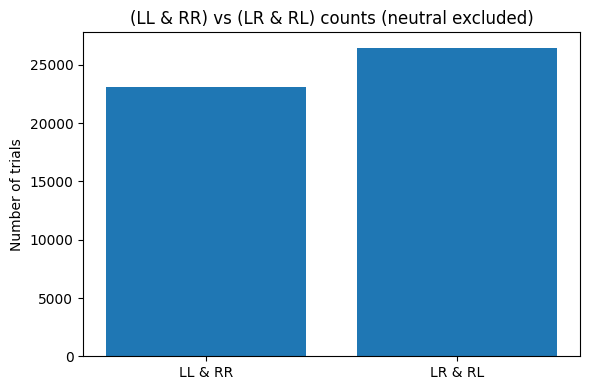

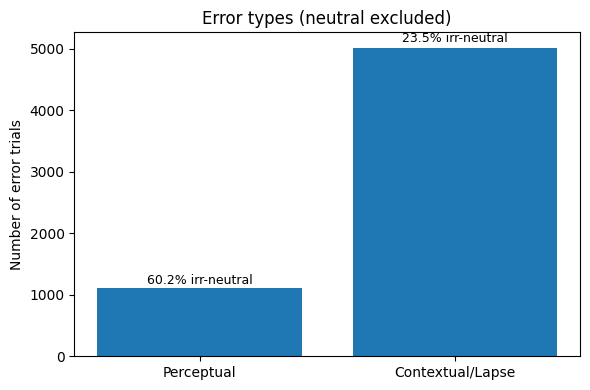

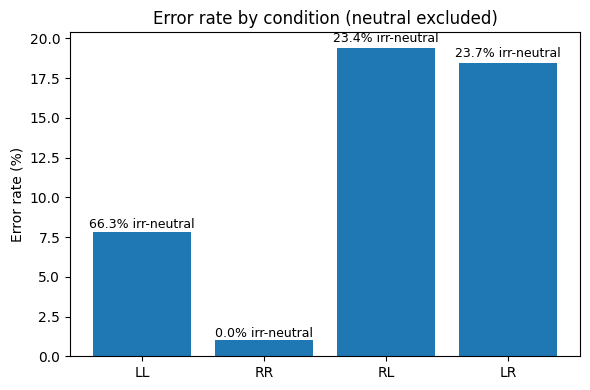

In [41]:

# =========================
# Plotting helpers
# =========================
def plot_bar(x, y, title, ylabel):
    plt.figure(figsize=(6, 4))
    plt.bar(x, y)
    plt.title(title)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


def make_correctness_plots(list_of_dfs):

    allowed = ['LL', 'RR', 'LR', 'RL', 'neutral']

    # 1) Percentage of trials in each group (incl. neutral)
    s = all_df['correctness_stim_type']
    group_pct = (
        s[s.isin(allowed)]
        .value_counts(normalize=True)
        .reindex(allowed, fill_value=0) * 100
    )
    plot_bar(group_pct.index.tolist(), group_pct.values.tolist(),
             "Trial distribution across groups (incl. neutral)",
             "Percentage of trials (%)")

    # 2) Counts for (LL & RR) vs (LR & RL) (neutral excluded)
    pair = np.where(all_df['correctness_stim_type'].isin(['LL','RR']), 'LL & RR',
            np.where(all_df['correctness_stim_type'].isin(['LR','RL']), 'LR & RL', 'exclude'))
    pair_counts = pd.Series(pair)
    pair_counts = pair_counts[pair_counts.isin(['LL & RR','LR & RL'])] \
        .value_counts().reindex(['LL & RR','LR & RL'], fill_value=0)
    plot_bar(pair_counts.index.tolist(), pair_counts.values.tolist(),
             "(LL & RR) vs (LR & RL) counts (neutral excluded)",
             "Number of trials")

    # 3) Error types with irr-neutral tracking (neutral excluded, is_correct!=2)
    valid = all_df[(all_df['is_correct'] != 2) &
                   (all_df['correctness_stim_type'].isin(['LL','RR','LR','RL']))].copy()
    err_only = valid[valid['is_correct'] == 0]

    per_err  = err_only[err_only['correctness_stim_type'].isin(['LL','RR'])]
    ctx_err  = err_only[err_only['correctness_stim_type'].isin(['LR','RL'])]

    err_counts = pd.Series({
        'Perceptual': len(per_err),
        'Contextual/Lapse': len(ctx_err)
    })
    # Plot counts
    plt.figure(figsize=(6, 4))
    plt.bar(err_counts.index, err_counts.values)
    plt.title("Error types (neutral excluded)")
    plt.ylabel("Number of error trials")
    # annotate % irr_neutral among the errors
    for i, key in enumerate(err_counts.index):
        if key == 'Perceptual':
            frac = (per_err['irr_neutral'].mean() * 100) if len(per_err) else 0
        else:
            frac = (ctx_err['irr_neutral'].mean() * 100) if len(ctx_err) else 0
        y = err_counts.iloc[i]
        plt.text(i, y * 1.01 if y > 0 else 0.1, f"{frac:.1f}% irr-neutral",
                 ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

    # 4) Error rate per condition (LL, RR, RL, LR), annotate irr-neutral share
    cond_df = valid.copy()
    cond_err_rate = (
        cond_df.groupby('correctness_stim_type')['is_correct']
        .apply(lambda x: (x == 0).mean() * 100)
        .reindex(['LL','RR','RL','LR'], fill_value=0)
    )
    plt.figure(figsize=(6, 4))
    plt.bar(cond_err_rate.index, cond_err_rate.values)
    plt.title("Error rate by condition (neutral excluded)")
    plt.ylabel("Error rate (%)")
    for i, cond in enumerate(cond_err_rate.index):
        cond_errs = cond_df[(cond_df['correctness_stim_type'] == cond) & (cond_df['is_correct'] == 0)]
        frac_irr = (cond_errs['irr_neutral'].mean() * 100) if len(cond_errs) else 0
        y = cond_err_rate.iloc[i]
        plt.text(i, y * 1.01 if y > 0 else 0.1, f"{frac_irr:.1f}% irr-neutral",
                 ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

    # (Optional) return combined DF if you want to inspect/save
    return all_df


# =========================
# Usage
# =========================
processed_all = make_correctness_plots(all_df)